# 5. Time-based split, labelled dataset and baseline model

**Step 2 of the churn project.**

Step 1 measured the buying rhythm but chose no threshold. Here we build the modelling dataset at
**two candidate churn definitions, 90 days and 120 days**, and fit a baseline model to each, so the
choice can be judged on evidence rather than convention.

The single most important thing in this step is that **the split respects time**. We never split
customers randomly to build the label. Instead we fix a snapshot date, build features only from
before it, and read the churn label only from after it. A random split would let the future leak
backwards into the features and quietly invalidate everything downstream.

**Decisions carried in (from CLAUDE.md and earlier steps):**
- Population is **repeat buyers only** — a customer must have **≥2 purchase occasions before the
  snapshot**. Single-purchase customers are a separate "never activated" problem, out of scope.
- Baseline model is **logistic regression** — boring and interpretable first. We report AUC only;
  pricing the errors on money is step 3.

*Expects `data.csv`, produced by `get_data.py`.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

## Load, clean, and collapse to purchase occasions

The same minimal cleaning as step 1: keep rows with a CustomerID, drop 'C' cancellations, and drop
non-positive quantity or price. We also compute the revenue of each line, then collapse to one row
per customer per calendar day, carrying that day's total spend — the unit we build features from.

In [2]:
df = pd.read_csv("data.csv", encoding="utf-8", parse_dates=["InvoiceDate"],
                 date_format="%m/%d/%Y %H:%M")
df = df[df["CustomerID"].notna()]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["revenue"] = df["Quantity"] * df["UnitPrice"]

# One purchase occasion = one customer on one calendar day, with that day's total
# spend. Same collapse as notebook 4, but summing revenue instead of counting lines.
timestamps = df["InvoiceDate"]
days = timestamps.dt.normalize()
df_with_day = df.assign(day=days)

grouped = df_with_day.groupby(["CustomerID", "day"], as_index=False)
purchases = grouped["revenue"].sum()

end_date = purchases["day"].max()
print(f"{len(purchases):,} purchase occasions, {purchases['CustomerID'].nunique():,} customers")
print(f"end date (anchor): {end_date.date()}")

16,763 purchase occasions, 4,338 customers
end date (anchor): 2011-12-09


## The snapshot construction

For a threshold *T*, the snapshot date is `C = end_date − T`. Everything on or before `C` is the
**observation window** (the only data the model may see). Everything after `C` is the **outcome
window** (used only to decide who churned). A customer is **churned** if they made no purchase in
the outcome window.

Features are the classic RFM set plus tenure and the average gap, all computed from the observation
window alone — so they are leak-free by construction. The function ends with **runnable assertions**
that fail loudly if any observation data strays past `C`, or if the label and the outcome window ever
disagree.

In [3]:
FEATURES = ["recency_days", "frequency", "tenure_days",
            "monetary_total", "monetary_avg", "avg_gap_days"]


def build_snapshot(T):
    # Cut the timeline in two at C. Nothing after C may reach the features.
    C = end_date - pd.Timedelta(days=T)
    obs = purchases[purchases["day"] <= C]      # observation window
    outcome = purchases[purchases["day"] > C]   # outcome window

    # Eligibility is judged on the observation window alone: 2+ purchases before C.
    g = obs.groupby("CustomerID")
    freq = g["day"].count()
    has_two_or_more = freq >= 2
    eligible = freq[has_two_or_more].index

    # Average gap, per eligible customer, within the observation window only.
    is_eligible_row = obs["CustomerID"].isin(eligible)
    obs_e = obs[is_eligible_row].sort_values(["CustomerID", "day"])
    gap_as_timedelta = obs_e.groupby("CustomerID")["day"].diff()
    gap = gap_as_timedelta.dt.days

    feat = pd.DataFrame(index=eligible)

    # Recency: days of silence as at C (not as at the end of the data).
    last_purchase = g["day"].max()
    silence_as_timedelta = C - last_purchase
    feat["recency_days"] = silence_as_timedelta.dt.days

    feat["frequency"] = freq

    # Tenure: how long the customer had been active by C.
    first_purchase = g["day"].min()
    tenure_as_timedelta = C - first_purchase
    feat["tenure_days"] = tenure_as_timedelta.dt.days

    feat["monetary_total"] = g["revenue"].sum()
    feat["monetary_avg"] = feat["monetary_total"] / feat["frequency"]

    gap_by_customer = gap.groupby(obs_e["CustomerID"])
    feat["avg_gap_days"] = gap_by_customer.mean()

    feat = feat.loc[eligible]

    # Churned = eligible customer with NO purchase in the outcome window.
    active_later = set(outcome["CustomerID"].unique())
    bought_later = feat.index.isin(active_later)
    feat["churned"] = (~bought_later).astype(int)

    # --- leakage guards: cheap, and worth failing on ---
    assert obs["day"].max() <= C, "observation data past the snapshot"
    assert outcome.empty or outcome["day"].min() > C, "outcome data on/before the snapshot"
    recomputed = (~bought_later).astype(int)
    assert (recomputed == feat["churned"].values).all(), "label disagrees with outcome window"

    return feat, C, obs, outcome

## Fit a baseline logistic regression at each threshold

The snapshot has already handled the temporal leakage, so within a single snapshot customers are
exchangeable and an ordinary random 70/30 split is a fair way to hold out a test set. We standardise
the features (so the coefficients are comparable) and fit a plain logistic regression. We keep the
default class weighting for the baseline and simply note the imbalance.

In [4]:
results = {}
for T in (90, 120):
    feat, C, obs, outcome = build_snapshot(T)
    y = feat["churned"]
    X = feat[FEATURES]

    obs_start = obs["day"].min()
    obs_length = (C - obs_start).days
    outcome_start = C + pd.Timedelta(days=1)

    print(f"===== T = {T} days =====")
    print(f"  observation window: {obs_start.date()} -> {C.date()} ({obs_length} days)")
    print(f"  outcome window:     {outcome_start.date()} -> {end_date.date()} ({T} days)")
    print(f"  eligible customers: {len(feat):,}")
    print(f"  churn rate:         {y.mean() * 100:.1f}%  ({int(y.sum()):,} churned / {len(y):,})")

    # The snapshot has already handled time, so a random split within it is fair.
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30,
                                          random_state=42, stratify=y)

    scaler = StandardScaler()                 # so coefficients are comparable
    logistic = LogisticRegression(max_iter=1000)
    model = make_pipeline(scaler, logistic)
    model.fit(Xtr, ytr)

    proba_both_classes = model.predict_proba(Xte)   # column 0 = stay, column 1 = churn
    proba = proba_both_classes[:, 1]

    auc = roc_auc_score(yte, proba)
    fpr, tpr, _ = roc_curve(yte, proba)

    fitted_logistic = model[-1]               # last step of the pipeline
    coef_values = fitted_logistic.coef_[0]    # one row, one weight per feature
    coefs = pd.Series(coef_values, index=FEATURES).sort_values()

    print(f"  test AUC:           {auc:.3f}")
    print("  standardised coefficients (+ pushes towards churn):")
    for name, val in coefs.items():
        print(f"    {name:>15}: {val:+.2f}")
    print()

    results[T] = {"auc": auc, "fpr": fpr, "tpr": tpr,
                  "n": len(feat), "churn_rate": y.mean(), "coefs": coefs}

===== T = 90 days =====
  observation window: 2010-12-01 -> 2011-09-10 (283 days)
  outcome window:     2011-09-11 -> 2011-12-09 (90 days)
  eligible customers: 1,956
  churn rate:         29.2%  (571 churned / 1,956)
  test AUC:           0.744
  standardised coefficients (+ pushes towards churn):
     monetary_total: -1.31
          frequency: -0.97
        tenure_days: -0.13
       avg_gap_days: +0.13
       monetary_avg: +0.30
       recency_days: +0.35

===== T = 120 days =====
  observation window: 2010-12-01 -> 2011-08-11 (253 days)
  outcome window:     2011-08-12 -> 2011-12-09 (120 days)
  eligible customers: 1,801
  churn rate:         23.0%  (414 churned / 1,801)
  test AUC:           0.743
  standardised coefficients (+ pushes towards churn):
     monetary_total: -1.02
          frequency: -0.47
        tenure_days: -0.46
       monetary_avg: +0.27
       avg_gap_days: +0.32
       recency_days: +0.66



## Feature profile of churned vs retained customers

In [5]:
for T in (90, 120):
    feat, *_ = build_snapshot(T)
    grouped_by_class = feat.groupby("churned")[FEATURES]
    class_means = grouped_by_class.mean().round(1)
    print(f"T = {T} days - mean feature by class (0 = retained, 1 = churned):")
    print(class_means.T)
    print()

T = 90 days - mean feature by class (0 = retained, 1 = churned):
churned              0       1
recency_days      50.9    81.2
frequency          5.6     2.9
tenure_days      215.7   200.3
monetary_total  3048.6  1077.6
monetary_avg     454.9   384.5
avg_gap_days      60.1    75.9

T = 120 days - mean feature by class (0 = retained, 1 = churned):
churned              0       1
recency_days      45.2    76.8
frequency          5.1     2.7
tenure_days      192.4   178.0
monetary_total  2756.1  1036.1
monetary_avg     455.3   393.9
avg_gap_days      59.2    70.6



## ROC curves

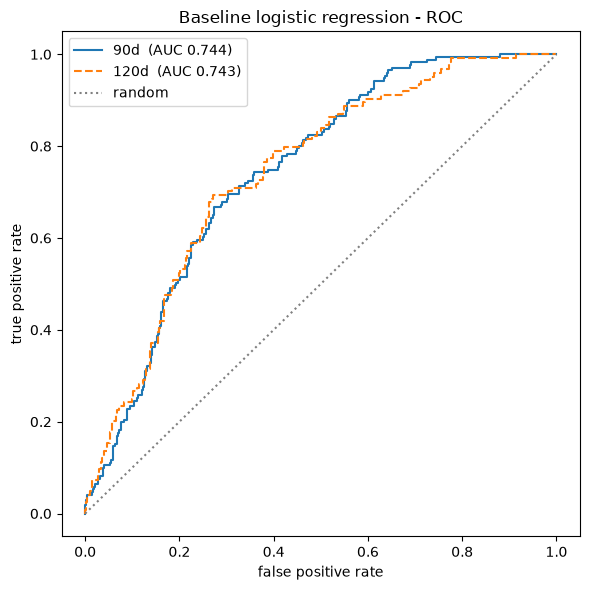

In [6]:
plt.figure(figsize=(6, 6))
for T, style in zip((90, 120), ("-", "--")):
    r = results[T]
    fpr = r["fpr"]
    tpr = r["tpr"]
    plt.plot(fpr, tpr, style, label=f"{T}d  (AUC {r['auc']:.3f})")

plt.plot([0, 1], [0, 1], ":", color="grey", label="random")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Baseline logistic regression - ROC")
plt.legend()
plt.tight_layout()
plt.show()

## Comparison and conclusion

In [7]:
summary_rows = {}
for T in (90, 120):
    r = results[T]
    summary_rows[T] = {
        "eligible customers": r["n"],
        "churn rate %": round(r["churn_rate"] * 100, 1),
        "test AUC": round(r["auc"], 3),
    }

summary = pd.DataFrame(summary_rows).T
summary.index.name = "threshold (days)"
summary

,eligible customers,churn rate %,test AUC
threshold (days),,,
90,1956.0,29.2,0.744
120,1801.0,23.0,0.743


### What this shows

Both thresholds produce a leak-free, labelled modelling set of repeat buyers, and in both cases a
plain logistic regression on six RFM-style features separates churners from stayers well above
chance — so the signal is real, not an artefact of the cut-off.

The two definitions differ in **who** they call a churner and **how balanced** the problem is: the
shorter 90-day window labels more customers as churned (a larger, more balanced positive class,
caught earlier but with more false alarms), while 120 days is a smaller, cleaner positive class
caught later. Which is preferable is not an AUC question — it depends on what a false alarm and a
miss actually cost, which is exactly what **step 3** prices. AUC alone should not decide it.

**Caveat, stated plainly:** the two thresholds use slightly different observation-window lengths
(283 vs 253 days), because the window shrinks as *T* grows against a fixed end date. This is inherent
to the data having only ~373 days, and it makes the two AUCs not perfectly like-for-like.

*No threshold is chosen here, and nothing beyond the baseline is built. Cost-based evaluation and
the no-model 90-day benchmark are steps 3 and 4.*